In [ ]:
!pip install matplotlib scipy

In [103]:
import json
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import t

In [ ]:
# Read constraints data
constraints_df = pd.read_csv('constraints.csv').reset_index(drop=True)
constraints_ldp_df = constraints_df[constraints_df['ldp'] == True]
constraints_ldp_df['constraints'] = constraints_ldp_df['non-linear constraints'] + constraints_ldp_df['linear constraints']
constraints_ldp_df = constraints_ldp_df[['k', 'constraints']]


constraints_no_ldp_df = constraints_df[constraints_df['ldp'] == False]
constraints_no_ldp_df['constraints'] = constraints_no_ldp_df['non-linear constraints'] + constraints_no_ldp_df['linear constraints']
constraints_no_ldp_df = constraints_no_ldp_df[['k', 'constraints']]

constraints_merged = pd.merge(constraints_no_ldp_df, constraints_ldp_df, on='k', suffixes=('_no_ldp', '_ldp'), how='outer')
constraints_merged = constraints_merged.rename(columns={'constraints_no_ldp': 'no_ldp_constraints', 'constraints_ldp': 'ldp_constraints'})


In [ ]:
constraints_merged['k'] = constraints_merged['k'].astype(int)

In [ ]:
# Generate LaTeX table
latex_table = "\\begin{table*}[htbp]\n"
latex_table += "\\centering\n"
latex_table += "\\caption{Number of constraints for different credential history sizes and the streaming algorithm implementation}\n"
latex_table += "\\label{tab:constraints}\n"
latex_table += "\\begin{tabular}{@{}lcc@{}}\n"
latex_table += "\\toprule\n"
latex_table += "Credential History Size & Constraints (Without RAPPOR) & Constraints (With RAPPOR) \\\\\n"
latex_table += "\\midrule\n"

for _, row in constraints_merged.sort_values('k').iterrows():
    k = row['k']
    if k == 'streaming':
        k_str = 'streaming'
    else:
        k_str = str(int(k))
    latex_table += f"{k_str} & "
    latex_table += f"{int(row['no_ldp_constraints']):,} & "
    latex_table += f"{int(row['ldp_constraints']):,} \\\\\n"
    # latex_table += "\\hline\n"

latex_table += "\\bottomrule\n"
latex_table += "\\end{tabular}\n"
latex_table += "\\end{table}"

print(latex_table)

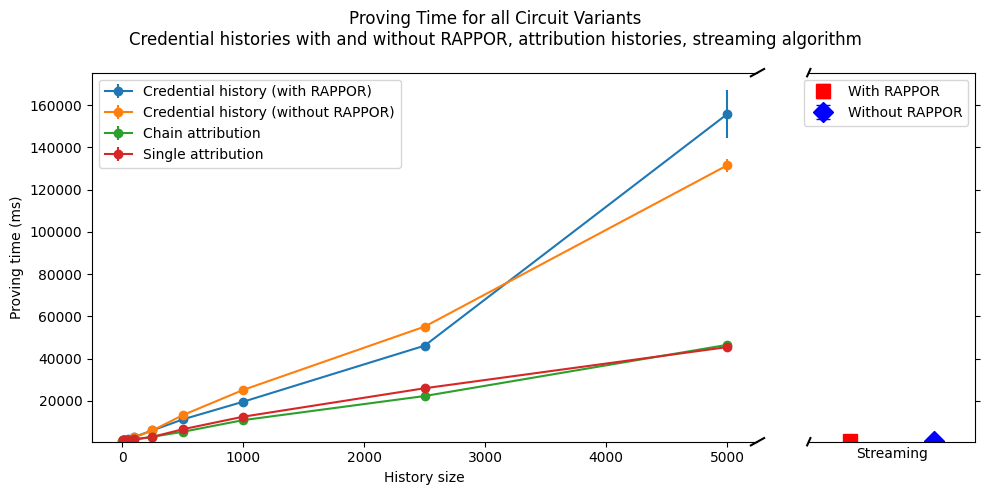

In [119]:
def load_results(path):
    with open(path, 'r') as f:
        data = json.load(f)
    data = [d for d in data if d.get('proveError') is None and d.get('verifyError') is None]
    prove = np.array([d['proveTimeMs'] for d in data])
    verify = np.array([d['verifyTimeMs'] for d in data])
    return prove, verify

def mean_ci(arr):
    n = len(arr)
    mean = np.mean(arr)
    stderr = np.std(arr, ddof=1) / np.sqrt(n)
    ci = t.ppf(0.975, n-1) * stderr
    return mean, ci

def get_k_from_filename(fname):
    return int(fname.split('_k')[-1].split('.')[0])

def aggregate_results(result_dir):
    files = sorted(glob(f"{result_dir}/experiment_results_k*.json"), key=get_k_from_filename)
    ks, means, cis, means_verify, cis_verify = [], [], [], [], []
    for f in files:
        k = get_k_from_filename(f)
        prove, verify = load_results(f)
        m, ci = mean_ci(prove)
        m_v, ci_v = mean_ci(verify)
        ks.append(k)
        means.append(m)
        cis.append(ci)
        means_verify.append(m_v)
        cis_verify.append(ci_v)
    return np.array(ks), np.array(means), np.array(cis), np.array(means_verify), np.array(cis_verify)

def load_streaming(result_dir):
    prove, verify = load_results(f"{result_dir}/experiment_results_streaming.json")
    m, ci = mean_ci(prove)
    m_v, ci_v = mean_ci(verify)
    return m, ci, m_v, ci_v

def plot_broken_axis(ldp_dir, noldp_dir,
                     attribution_chain_dir, attribution_single_dir,
                     streaming_ldp_dir, streaming_noldp_dir, title_prefix=""):
    ks, means, cis, means_verify, cis_verify = aggregate_results(ldp_dir)
    ks_noldp, means_noldp, cis_noldp, means_verify_noldp, cis_verify_noldp = aggregate_results(noldp_dir)
    ks_chain, means_chain, cis_chain, means_verify_chain, cis_verify_chain = aggregate_results(attribution_chain_dir) 
    ks_single, means_single, cis_single, means_verify_single, cis_verify_single = aggregate_results(attribution_single_dir) 

    # Streaming
    m_stream_ldp, ci_stream_ldp, m_v_stream_ldp, ci_v_stream_ldp = load_streaming(streaming_ldp_dir)
    m_stream_noldp, ci_stream_noldp, m_v_stream_noldp, ci_v_stream_noldp = load_streaming(streaming_noldp_dir)

    # Proving time
    fig, (ax_main, ax_stream) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [4, 1]}, sharey=True, figsize=(10,5))
    fig.suptitle(f'{title_prefix}Proving Time for all Circuit Variants\nCredential histories with and without RAPPOR, attribution histories, streaming algorithm')
    
    # Main plot
    ax_main.errorbar(ks, means, yerr=cis, fmt='-o', label='Credential history (with RAPPOR)')
    ax_main.errorbar(ks_noldp, means_noldp, yerr=cis_noldp, fmt='-o', label='Credential history (without RAPPOR)')
    ax_main.errorbar(ks_chain, means_chain, yerr=cis_chain, fmt='-o', label='Chain attribution')
    ax_main.errorbar(ks_single, means_single, yerr=cis_single, fmt='-o', label='Single attribution')
    ax_main.set_xlabel('History size')
    ax_main.set_ylabel('Proving time (ms)')
    # Set y-axis limits to start slightly below minimum value
    y_min = min(np.min(means - cis), np.min(means_noldp - cis_noldp))
    ax_main.set_ylim(bottom=y_min * 0.8)
    # ax_main.set_title(f'{title_prefix}Proving Time')
    ax_main.legend()
    # Remove right spine
    ax_main.spines['right'].set_visible(False)
    ax_main.yaxis.tick_left()
    ax_main.tick_params(labelright=False)
    # Streaming plot
    ax_stream.errorbar([1], [m_stream_ldp], yerr=[ci_stream_ldp], fmt='s', color='red', label='With RAPPOR', markersize=10, capsize=5)
    ax_stream.errorbar([2], [m_stream_noldp], yerr=[ci_stream_noldp], fmt='D', color='blue', label='Without RAPPOR', markersize=10, capsize=5)
    ax_stream.set_xticks([])
    ax_stream.set_xlim(0.5,2.5)
    ax_stream.set_xlabel('Streaming')
    ax_stream.legend(loc='upper right')
    ax_stream.spines['left'].set_visible(False)
    ax_stream.yaxis.tick_right()
    # Diagonal lines to indicate break
    d = .01
    kwargs = dict(transform=ax_main.transAxes, color='k', clip_on=False)
    ax_main.plot([1-d,1+d], [-d,+d], **kwargs)
    ax_main.plot([1-d,1+d],[1-d,1+d], **kwargs)
    kwargs.update(transform=ax_stream.transAxes)
    ax_stream.plot([-d,+d], [1-d,1+d], **kwargs)
    ax_stream.plot([-d,+d], [-d,+d], **kwargs)
    plt.tight_layout()
    # plt.savefig("graphics/proving.pdf")
    plt.show()

    # # Verifying time (linear y)
    # fig, (ax_main, ax_stream) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [4, 1]}, sharey=True, figsize=(10,5))
    # fig.suptitle(f'{title_prefix}Verifying Time for Varying Credential History Size and Streaming')
    # ax_main.errorbar(ks, means_verify, yerr=cis_verify, fmt='-o', label='With RAPPOR')
    # ax_main.errorbar(ks_noldp, means_verify_noldp, yerr=cis_verify_noldp, fmt='-o', label='Without RAPPOR')
    # # ax_main.set_xscale('log')
    # ax_main.set_xlabel('Credential history size')
    # ax_main.set_ylabel('Verifying time (ms)')
    # ax_main.legend(loc='upper left')
    # ax_main.spines['right'].set_visible(False)
    # ax_main.yaxis.tick_left()
    # ax_main.tick_params(labelright=False)
    # ax_stream.errorbar([1], [m_v_stream_ldp], yerr=[ci_v_stream_ldp], fmt='s', color='red', label='With RAPPOR', markersize=10, capsize=5)
    # ax_stream.errorbar([2], [m_v_stream_noldp], yerr=[ci_v_stream_noldp], fmt='D', color='blue', label='Without RAPPOR', markersize=10, capsize=5)
    # ax_stream.set_xlabel('Streaming')
    # ax_stream.set_xlim(0.5,2.5)
    # ax_stream.set_xticks([])  # Remove x ticks
    # ax_stream.legend(loc='upper right')
    # ax_stream.spines['left'].set_visible(False)
    # ax_stream.yaxis.tick_right()
    # d = .01
    # kwargs = dict(transform=ax_main.transAxes, color='k', clip_on=False)
    # ax_main.plot([1-d,1+d], [-d,+d], **kwargs)
    # ax_main.plot([1-d,1+d],[1-d,1+d], **kwargs)
    # kwargs.update(transform=ax_stream.transAxes)
    # ax_stream.plot([-d,+d], [1-d,1+d], **kwargs)
    # ax_stream.plot([-d,+d], [-d,+d], **kwargs)
    # plt.tight_layout()
    # # plt.savefig("graphics/verifying.pdf")
    # plt.show()

# --- Usage ---
plot_broken_axis(
    ldp_dir="results_ldp",
    noldp_dir="results_no_ldp",
    streaming_ldp_dir="results_ldp",
    streaming_noldp_dir="results_no_ldp",
    attribution_chain_dir="results_attribution_chain",
    attribution_single_dir="results_attribution_single"
)

[<matplotlib.lines.Line2D object at 0x11e7d62c0>, <matplotlib.lines.Line2D object at 0x11c780880>, <ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>]
['Streaming (with RAPPOR)', 'Streaming (without RAPPOR)', 'Credential history (with RAPPOR)', 'Credential history (without RAPPOR)', 'Chain attribution', 'Single attribution']


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_71689/836392438.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.93, 0.95])  # leave space for legend


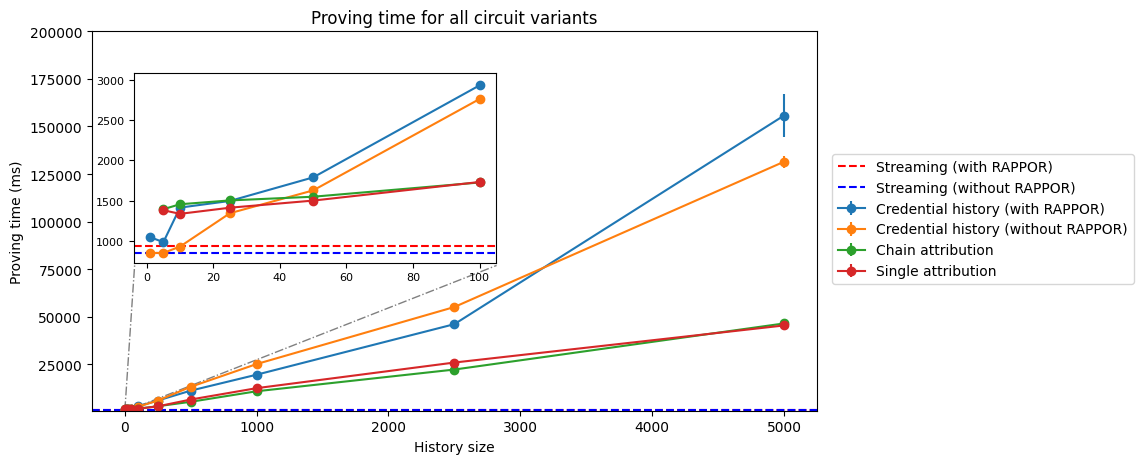

In [161]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch



ks, means, cis, _, _ = aggregate_results("results_ldp")
ks_noldp, means_noldp, cis_noldp, _, _ = aggregate_results("results_no_ldp")
ks_chain, means_chain, cis_chain, _, _ = aggregate_results("results_attribution_chain") 
ks_single, means_single, cis_single, _, _ = aggregate_results("results_attribution_single") 
# Streaming
m_stream_ldp, ci_stream_ldp, _, _ = load_streaming("results_ldp")
m_stream_noldp, ci_stream_noldp, _, _ = load_streaming("results_no_ldp")


# fig, (ax_main, ax_stream) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [4, 1]}, sharey=True)

fig, ax_main = plt.subplots(1, 1, figsize=(9, 5))

# Main plot: all four time series
main_lines = []
main_lines += ax_main.errorbar(ks, means, yerr=cis, fmt='-o', label='Credential history (with RAPPOR)').lines
main_lines += ax_main.errorbar(ks_noldp, means_noldp, yerr=cis_noldp, fmt='-o', label='Credential history (without RAPPOR)').lines
main_lines += ax_main.errorbar(ks_chain, means_chain, yerr=cis_chain, fmt='-o', label='Chain attribution').lines
main_lines += ax_main.errorbar(ks_single, means_single, yerr=cis_single, fmt='-o', label='Single attribution').lines

ax_main.set_xlabel('History size')
ax_main.set_ylabel('Proving time (ms)')
ax_main.set_ylim(0, 200_000)
ax_main.set_title('Proving time for all circuit variants')
y_min = min(np.min(means - cis), np.min(means_noldp - cis_noldp), np.min(means_chain - cis_chain), np.min(means_single - cis_single))
ax_main.set_ylim(bottom=y_min * 0.8)
ax_main.axhline(m_stream_ldp, color='red', linestyle='--', label='Streaming (with RAPPOR)')
ax_main.axhline(m_stream_noldp, color='blue', linestyle='--', label='Streaming (without RAPPOR)')

# ax_main.spines['right'].set_visible(False)
ax_main.yaxis.tick_left()
ax_main.tick_params(labelright=False)

# Inset: zoom in on small history sizes, top left
ax_inset = inset_axes(ax_main, width="50%", height="50%", loc='upper left', borderpad=3)
mask = (ks <= 100)
mask_chain = (ks_chain <= 100)
mask_single = (ks_single <= 100)
ax_inset.errorbar(ks[mask], means[mask], yerr=cis[mask], fmt='-o')
ax_inset.errorbar(ks_noldp[mask], means_noldp[mask], yerr=cis_noldp[mask], fmt='-o')
ax_inset.errorbar(ks_chain[mask_chain], means_chain[mask_chain], yerr=cis_chain[mask_chain], fmt='-o')
ax_inset.errorbar(ks_single[mask_single], means_single[mask_single], yerr=cis_single[mask_single], fmt='-o')
ax_inset.axhline(m_stream_ldp, color='red', linestyle='--', label='Streaming (with RAPPOR)')
ax_inset.axhline(m_stream_noldp, color='blue', linestyle='--', label='Streaming (without RAPPOR)')
ax_inset.tick_params(axis='both', which='major', labelsize=8)

# Coordinates for the region in the main plot (in data coordinates)
x1, x2 = min(ks[mask]), max(ks[mask])
y1, y2 = min(means[mask]), max(means[mask])

# Lower left
xy_main1 = (x1, means[mask][0])
xy_inset1 = (x1, means[mask][0])
# Upper right
xy_main2 = (x2, means[mask][-1])
xy_inset2 = (x2, means[mask][-1])

ax_main.plot([x1, 75], [y1, 77000], color='gray', linestyle='-.', linewidth=1)
ax_main.plot([x2, 2820], [y2, 77000], color='gray', linestyle='-.', linewidth=1)



# # Create connection patches
# con1 = ConnectionPatch(xyA=xy_inset1, coordsA=ax_inset.transData,
#                        xyB=xy_main1, coordsB=ax_main.transData,
#                        color="gray", linewidth=1, arrowstyle="->")
# con2 = ConnectionPatch(xyA=xy_inset2, coordsA=ax_inset.transData,
#                        xyB=xy_main2, coordsB=ax_main.transData,
#                        color="gray", linewidth=1, arrowstyle="->")

# Add to the figure
# fig.add_artist(con1)
# fig.add_artist(con2)

# # Streaming plot: only streaming data
# ax_stream.errorbar([1], [m_stream_ldp], yerr=[ci_stream_ldp], fmt='s', color='red', label='Streaming (with RAPPOR)', markersize=10, capsize=5)
# ax_stream.errorbar([2], [m_stream_noldp], yerr=[ci_stream_noldp], fmt='D', color='blue', label='Streaming (without RAPPOR)', markersize=10, capsize=5)
# ax_stream.set_xticks([1, 2])
# ax_stream.set_xticklabels(['With RAPPOR', 'Without RAPPOR'])
# ax_stream.set_xlabel('Streaming')
# ax_stream.spines['left'].set_visible(False)
# ax_stream.yaxis.tick_right()

# Legend outside the main plot
handles, labels = ax_main.get_legend_handles_labels()
print(handles)
print(labels)

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.93, 0.5), borderaxespad=0., fontsize=10)

plt.tight_layout(rect=[0, 0, 0.93, 0.95])  # leave space for legend
plt.savefig("graphics/proving_v3.pdf", bbox_inches='tight')
plt.show()

In [162]:
ldp = aggregate_results("results_ldp")
noldp = aggregate_results("results_no_ldp")
chain = aggregate_results("results_attribution_chain")
single = aggregate_results("results_attribution_single")

ldp_stream = load_streaming("results_ldp")
noldp_stream = load_streaming("results_no_ldp")






In [114]:
print("LDP results:")
print(ldp)
print("No LDP results:")
print(noldp)
print("Chain results:")
print(chain)
print("Single results:")
print(single)

LDP results:
(array([   1,    5,   10,   25,   50,  100,  250,  500, 1000, 2500, 5000]), array([  1046.27503957,    983.37627937,   1413.46747265,   1496.52642456,
         1789.6485923 ,   2935.11662918,   6015.1812329 ,  11215.25363177,
        19595.09473734,  46148.50742167, 155765.66574006]), array([   44.02523063,    19.02014312,    43.62262265,    19.64648779,
          33.62955056,    46.04798677,   104.91277058,   140.34889745,
         275.82014116,   846.50245127, 11298.30492512]), array([12.51588592, 12.91664058, 13.3986953 , 12.94932099, 13.20860278,
       14.31938677, 13.68575684, 11.54984991, 11.46717898, 13.73350549,
       25.10630595]), array([0.75479337, 0.91076876, 0.49651387, 0.30332588, 0.36721409,
       0.40030459, 1.90236807, 0.24090658, 0.28051886, 0.67883224,
       2.47412723]))
No LDP results:
(array([   1,    5,   10,   25,   50,  100,  250,  500, 1000, 2500, 5000]), array([   849.37625707,    849.45701808,    928.23555201,   1343.78648137,
         1627.

In [163]:
print(ldp_stream)
print(noldp_stream)

(np.float64(938.8318162699999), np.float64(15.506860039818257), np.float64(14.49892741), np.float64(0.3066443320212737))
(np.float64(851.3379564699999), np.float64(17.361955094046476), np.float64(14.444693910000002), np.float64(0.459575936299657))


In [102]:
df = pd.read_csv('results_web.csv')
print("Proving time statistics:")
print(f"Mean: {df['proving_time'].mean():.2f} ms")
print(f"Std dev: {df['proving_time'].std():.2f} ms")
print("\nVerifying time statistics:")
print(f"Mean: {df['verifying_time'].mean():.2f} ms")
print(f"Std dev: {df['verifying_time'].std():.2f} ms")

Proving time statistics:
Mean: 1473.24 ms
Std dev: 160.19 ms

Verifying time statistics:
Mean: 51.83 ms
Std dev: 13.06 ms
